,count,mean,std,min,25%,50%,75%,max
RMSE,442.0,44.355723,32.19733,0.208637,18.485262,39.548204,63.974315,158.233013


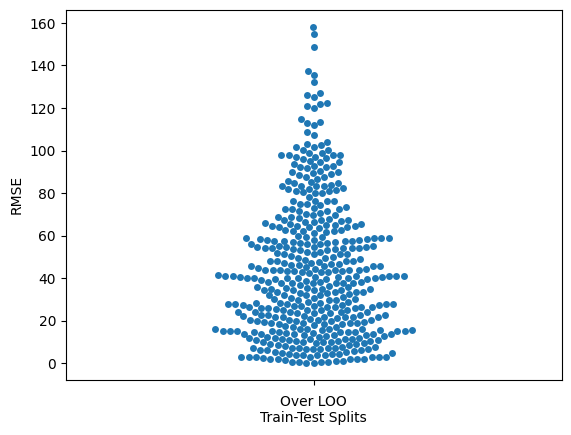

In [ ]:
from sklearn import linear_model, datasets, model_selection as skms
import numpy as np
import pandas as pd
import seaborn as sns

linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()
loo = skms.LeaveOneOut()
scores = skms.cross_val_score(linreg,
  diabetes.data, diabetes.target,
  cv=loo,
  scoring='neg_mean_squared_error')
scores = pd.Series(np.sqrt(-scores))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'
display(df.describe().T)
ax = sns.swarmplot(y='RMSE', data=df)
ax.set_xlabel('Over LOO\nTrain-Test Splits');